In [1]:
CorbinFL_dir = "checkpoints/CorbinFL_MNIST_20250127_123255"
ldpfl_dir = "checkpoints/LDPFL_MNIST_20250127_123050"

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

def load_and_process_all_layers(checkpoint_dir, round=0):
    """Load and process updates from all layers."""
    before_updates = torch.load(f"{checkpoint_dir}/round_{round}_updates_before.pt")
    after_updates = torch.load(f"{checkpoint_dir}/round_{round}_updates_after.pt")
    C, R = torch.load(f"{checkpoint_dir}/round_{round}_CR.pt")
    
    # Get all layer names from the first update
    layer_names = [name for name in before_updates[0].keys() if 'weight' in name]
    
    layer_data = {}
    for i, layer_name in enumerate(layer_names):
        # Extract all weights for current layer
        layer_before = torch.stack([update[layer_name].flatten().cpu() for update in before_updates])
        layer_after = torch.stack([update[layer_name].flatten().cpu() for update in after_updates])
        
        layer_C = C[i].cpu().item()
        layer_R = R[i].cpu().item()
        
        # Calculate statistics
        pre_quant_avg = layer_before.mean(dim=0)
        post_quant_avg = layer_after.mean(dim=0)
        
        layer_data[layer_name] = {
            'pre_quant_avg': pre_quant_avg,
            'post_quant_avg': post_quant_avg,
            'num_clients': len(before_updates),
            'C': layer_C,
            'R': layer_R
        }
    
    return layer_data

def plot_pca_all_weights_improved(method1_dir, method2_dir, num_rounds, save_path=None, layer_subset=None):
    """Create a publication-quality PCA plot comparing quantization errors across rounds."""
    # Set up publication-quality plotting style
    # plt.style.use('seaborn-paper')
    plt.rcParams.update({
        'font.family': 'serif',
        'axes.labelsize': 9,
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
        'legend.fontsize': 8,
        'figure.dpi': 300,
        'text.usetex': False
    })

    # Process data
    method1_data = load_and_process_all_layers(method1_dir, round=0)
    layer_names = list(method1_data.keys()) if layer_subset is None else layer_subset
    
    method1_all_distances = []
    method2_all_distances = []
    
    for round_num in range(num_rounds):
        try:
            method1_data = load_and_process_all_layers(method1_dir, round=round_num)
            method2_data = load_and_process_all_layers(method2_dir, round=round_num)
            
            if round_num == 0:
                for layer_name in layer_names:
                    m1_distances = method1_data[layer_name]['post_quant_avg'] - method1_data[layer_name]['pre_quant_avg']
                    m2_distances = method2_data[layer_name]['post_quant_avg'] - method2_data[layer_name]['pre_quant_avg']
                    
                    method1_all_distances.append(torch.zeros((len(m1_distances), num_rounds)))
                    method2_all_distances.append(torch.zeros((len(m2_distances), num_rounds)))
                    
                    method1_all_distances[-1][:, 0] = m1_distances
                    method2_all_distances[-1][:, 0] = m2_distances
            else:
                for layer_idx, layer_name in enumerate(layer_names):
                    m1_distances = method1_data[layer_name]['post_quant_avg'] - method1_data[layer_name]['pre_quant_avg']
                    m2_distances = method2_data[layer_name]['post_quant_avg'] - method2_data[layer_name]['pre_quant_avg']
                    
                    method1_all_distances[layer_idx][:, round_num] = m1_distances
                    method2_all_distances[layer_idx][:, round_num] = m2_distances
        except FileNotFoundError as e:
            print(f"Warning: {e}")
            continue

    # Process data for PCA
    method1_combined = torch.cat(method1_all_distances, dim=0)
    method2_combined = torch.cat(method2_all_distances, dim=0)
    
    m1_np = method1_combined.numpy()
    m2_np = method2_combined.numpy()
    
    max_points = 10000
    if len(m1_np) > max_points:
        indices = np.random.choice(len(m1_np), max_points, replace=False)
        m1_np = m1_np[indices]
        m2_np = m2_np[indices]

    # PCA implementation
    combined_data = np.vstack([m1_np, m2_np])
    pca = PCA(n_components=2)
    embedded_data = pca.fit_transform(combined_data)
    
    m1_embedded = embedded_data[:len(m1_np)]
    m2_embedded = embedded_data[len(m1_np):]

    def confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
        if x.size != y.size:
            raise ValueError("x and y must be the same size")

        cov = np.cov(x, y)
        pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
        
        ell_radius_x = np.sqrt(1 + pearson)
        ell_radius_y = np.sqrt(1 - pearson)
        ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2,
                         **kwargs)
        
        scale_x = np.sqrt(cov[0, 0]) * n_std
        scale_y = np.sqrt(cov[1, 1]) * n_std
        
        transf = transforms.Affine2D() \
            .rotate_deg(45) \
            .scale(scale_x, scale_y) \
            .translate(np.mean(x), np.mean(y))
        
        ellipse.set_transform(transf + ax.transData)
        return ax.add_patch(ellipse)

    # Calculate density estimates
    m1_xy = np.vstack([m1_embedded[:, 0], m1_embedded[:, 1]])
    m2_xy = np.vstack([m2_embedded[:, 0], m2_embedded[:, 1]])
    
    m1_z = gaussian_kde(m1_xy, bw_method='scott')(m1_xy)
    m2_z = gaussian_kde(m2_xy, bw_method='scott')(m2_xy)
    
    m1_idx = m1_z.argsort()
    m2_idx = m2_z.argsort()

     # Create figure with nested GridSpec
    fig = plt.figure(figsize=(6.5, 3.5))
    
    # Create outer GridSpec with two columns: one for plots, one for colorbar
    outer_gs = gridspec.GridSpec(1, 2, width_ratios=[20, 1], wspace=0.05)
    
    # Create nested GridSpec for the plots
    gs_plots = gridspec.GridSpecFromSubplotSpec(2, 2, 
                                              subplot_spec=outer_gs[0],
                                              height_ratios=[3, 1],
                                              wspace=0.4,
                                              hspace=0.5)
    
    # Create subplot for colorbar
    cax = plt.subplot(outer_gs[1])

    # Create main plot axes
    ax1 = plt.subplot(gs_plots[0, 0])
    ax2 = plt.subplot(gs_plots[0, 1])
    ax1_dist = plt.subplot(gs_plots[1, 0])
    ax2_dist = plt.subplot(gs_plots[1, 1])

    colors = sns.color_palette("colorblind")

    # Calculate global limits for consistent axes
    all_embedded = np.vstack([m1_embedded, m2_embedded])
    global_limit = 0.5

    # Plot main scatter plots
    for ax, data, color, method in zip([ax1, ax2], 
                                     [(m1_embedded, m1_z, m1_idx), 
                                      (m2_embedded, m2_z, m2_idx)],
                                     [colors[0], colors[1]],
                                     ['CorBin-FL', 'Independent']):
        embedded, density, idx = data
        
        scatter = ax.scatter(embedded[idx, 0], embedded[idx, 1],
                           c=density[idx], cmap='viridis',
                           alpha=0.6, s=10, rasterized=True)
        
        confidence_ellipse(embedded[:, 0], embedded[:, 1], ax,
                         n_std=2.0, facecolor=color, alpha=0.2)
        
        ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
        ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
        ax.set_title(f'{method}', fontsize=9)
        ax.grid(True, linestyle='--', alpha=0.3)
        
        # Use global limits
        ax.set_xlim(-global_limit, global_limit)
        ax.set_ylim(-global_limit, global_limit)

    # Add colorbar
    cbar = plt.colorbar(scatter, cax=cax)
    cbar.set_label('Density', fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    # Add distribution plots
    for ax_dist, embedded, color in zip([ax1_dist, ax2_dist],
                                      [m1_embedded, m2_embedded],
                                      [colors[0], colors[1]]):
        sns.kdeplot(data=embedded[:, 0], ax=ax_dist, color=color)
        ax_dist.set_xlabel('PC1', fontsize=8)
        ax_dist.set_ylabel('Density', fontsize=8)
        ax_dist.tick_params(labelsize=7)
        
        # Set consistent x-limits for distribution plots
        ax_dist.set_xlim(-global_limit, global_limit)

    plt.suptitle('Quantization Error Distribution', fontsize=10)
    plt.tight_layout()

    if save_path:
        plt.savefig(f"{save_path}.pdf", bbox_inches='tight', dpi=300)
        plt.savefig(f"{save_path}.png", bbox_inches='tight', dpi=300)
        plt.savefig(f"{save_path}_highres.png", bbox_inches='tight', dpi=600)

    return {
        'pca': pca,
        'embeddings': (m1_embedded, m2_embedded),
        'explained_variance_ratio': pca.explained_variance_ratio_
    }

/tmp/ipykernel_2399142/2851103652.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  before_updates = torch.load(f"{checkpoint_dir}/round_{round}_updates_before.pt")
/tmp/

{'pca': PCA(n_components=2),
 'embeddings': (array([[-0.00318638,  0.00045577],
         [-0.00171131, -0.00142835],
         [-0.06298376,  0.00665693],
         ...,
         [ 0.00322389, -0.00270589],
         [-0.00218224,  0.00149769],
         [-0.00413496, -0.00417284]], dtype=float32),
  array([[-0.02853104, -0.1922867 ],
         [-0.2789471 ,  0.03802182],
         [ 0.03212304, -0.06698196],
         ...,
         [ 0.04506901, -0.16184086],
         [ 0.20560846, -0.09963632],
         [ 0.42188695,  0.06985143]], dtype=float32)),
 'explained_variance_ratio': array([0.14192665, 0.11335977], dtype=float32)}

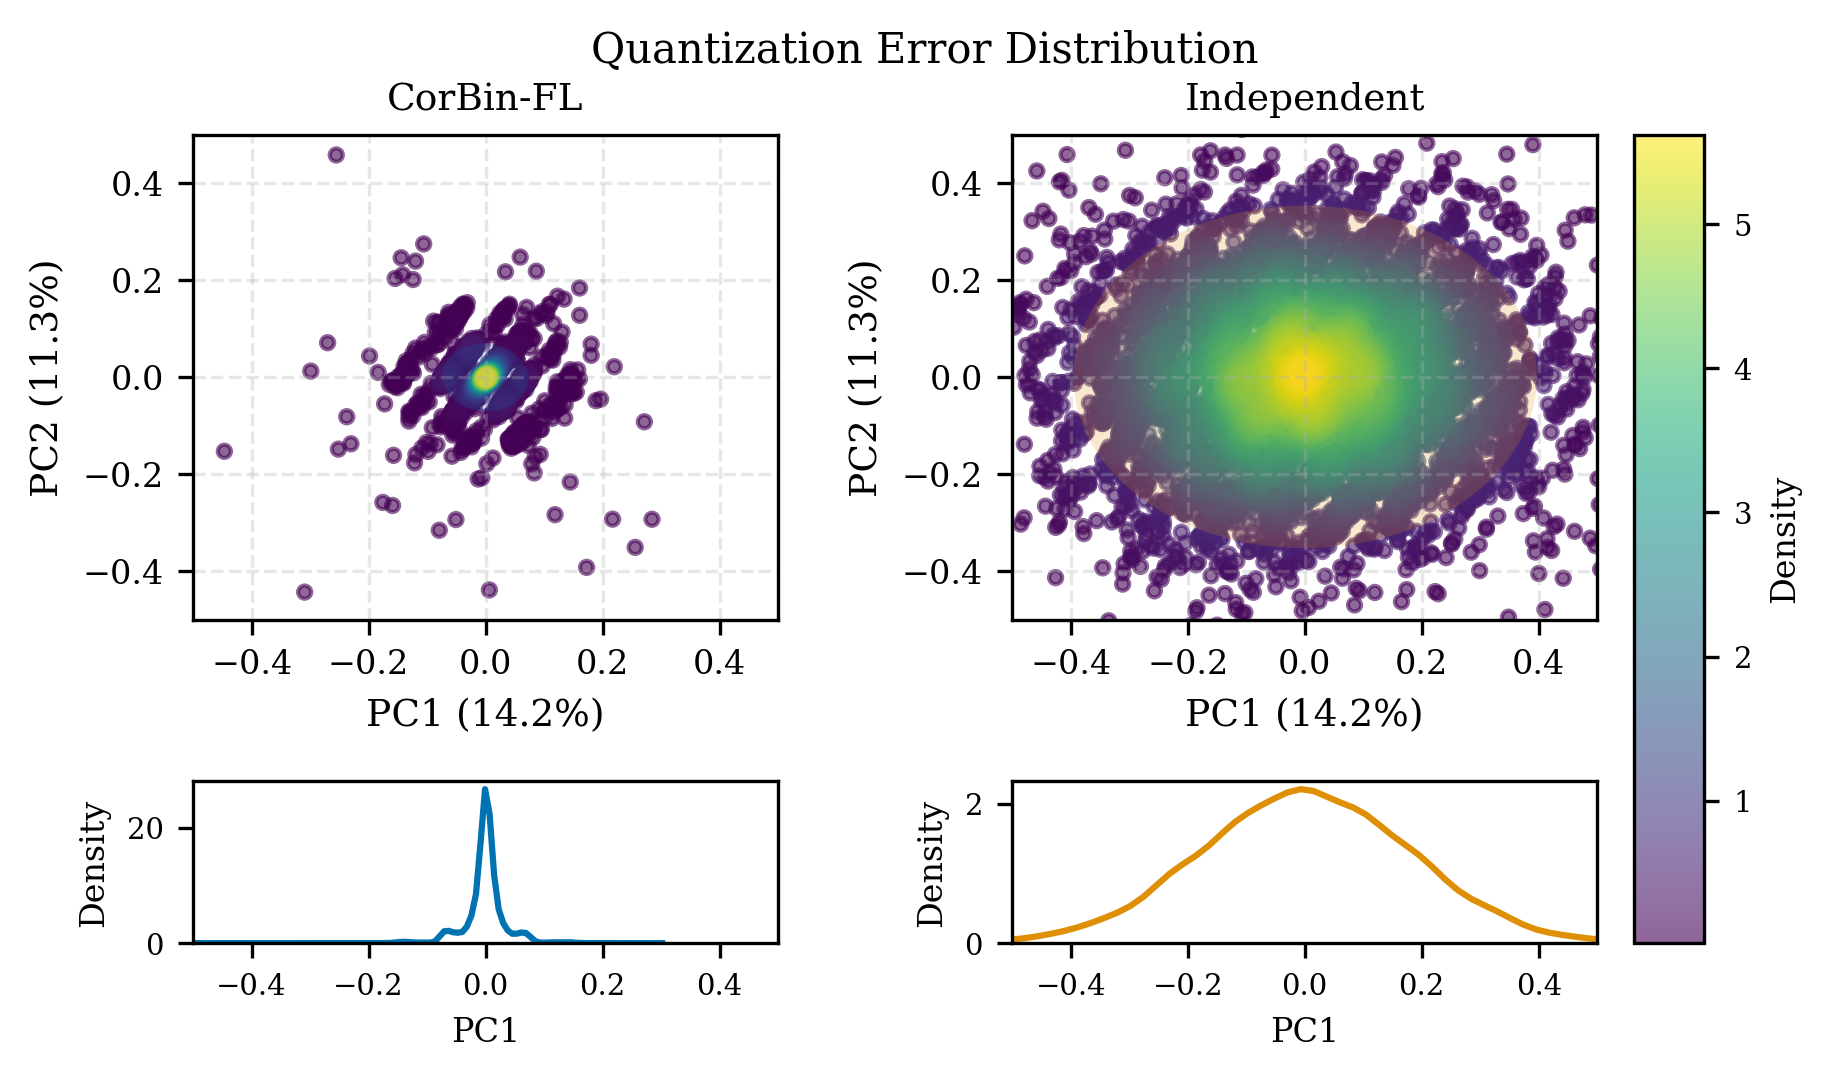

In [3]:
plot_pca_all_weights_improved(CorbinFL_dir, ldpfl_dir, num_rounds=20, save_path='pca_all_weights.png')

/tmp/ipykernel_56164/4240806800.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  before_updates = torch.load(f"{checkpoint_dir}/round_{round}_updates_before.pt")
/tmp/ipy

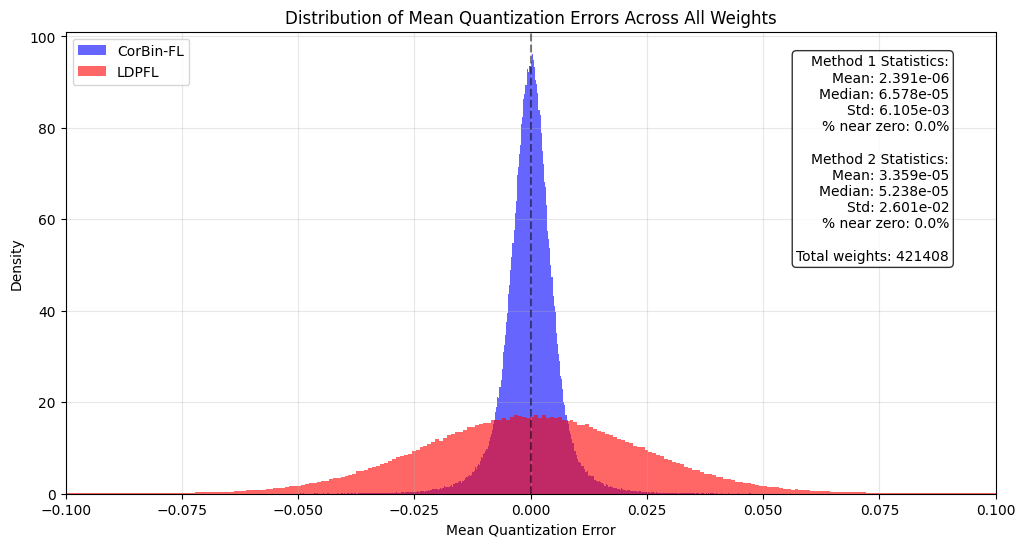

In [ ]:
def plot_error_distribution_comparison(method1_dir, method2_dir, num_rounds, save_path=None):
    """
    Create histogram comparing mean error distribution between two methods.
    """
    # First get all layer names from first round
    method1_data = load_and_process_all_layers(method1_dir, round=0)
    layer_names = list(method1_data.keys())
    
    # Initialize lists to store all distances
    method1_all_distances = []
    method2_all_distances = []
    
    # Process each round and layer
    for round_num in range(num_rounds):
        method1_data = load_and_process_all_layers(method1_dir, round=round_num)
        method2_data = load_and_process_all_layers(method2_dir, round=round_num)
        
        # For first round, initialize the distance tensors
        if round_num == 0:
            for layer_name in layer_names:
                m1_distances = method1_data[layer_name]['post_quant_avg'] - method1_data[layer_name]['pre_quant_avg']
                m2_distances = method2_data[layer_name]['post_quant_avg'] - method2_data[layer_name]['pre_quant_avg']
                
                # Initialize tensors for this layer
                method1_all_distances.append(torch.zeros((len(m1_distances), num_rounds)))
                method2_all_distances.append(torch.zeros((len(m2_distances), num_rounds)))
                
                # Store the distances for first round
                method1_all_distances[-1][:, 0] = m1_distances
                method2_all_distances[-1][:, 0] = m2_distances
        else:
            # For subsequent rounds, fill in the distances
            for layer_idx, layer_name in enumerate(layer_names):
                m1_distances = method1_data[layer_name]['post_quant_avg'] - method1_data[layer_name]['pre_quant_avg']
                m2_distances = method2_data[layer_name]['post_quant_avg'] - method2_data[layer_name]['pre_quant_avg']
                
                method1_all_distances[layer_idx][:, round_num] = m1_distances
                method2_all_distances[layer_idx][:, round_num] = m2_distances
    
    # Concatenate all distances
    method1_combined = torch.cat(method1_all_distances, dim=0)
    method2_combined = torch.cat(method2_all_distances, dim=0)
    
    # Calculate mean error for each weight across rounds
    method1_mean_errors = torch.mean(method1_combined, dim=1).numpy()
    method2_mean_errors = torch.mean(method2_combined, dim=1).numpy()
    
    # Create figure
    plt.figure(figsize=(12, 6))
    
    # Calculate optimal number of bins using Freedman-Diaconis rule
    def get_optimal_bins(data):
        iqr = np.percentile(data, 75) - np.percentile(data, 25)
        bin_width = 2 * iqr / (len(data) ** (1/3))
        if bin_width == 0:
            return int(np.sqrt(len(data)))
        return int((np.max(data) - np.min(data)) / bin_width)
    
    n_bins = min(get_optimal_bins(method1_mean_errors), get_optimal_bins(method2_mean_errors))
    
    # Plot histograms
    plt.hist(method1_mean_errors, bins=n_bins, alpha=0.6, color='blue', 
             label='CorBin-FL', density=True)
    plt.hist(method2_mean_errors, bins=n_bins, alpha=0.6, color='red', 
             label='LDPFL', density=True)
    
    # Add statistical information
    stats_text = (
        f'Method 1 Statistics:\n'
        f'Mean: {np.mean(method1_mean_errors):.3e}\n'
        f'Median: {np.median(method1_mean_errors):.3e}\n'
        f'Std: {np.std(method1_mean_errors):.3e}\n'
        f'% near zero: {np.mean(np.abs(method1_mean_errors) < 1e-6)*100:.1f}%\n\n'
        f'Method 2 Statistics:\n'
        f'Mean: {np.mean(method2_mean_errors):.3e}\n'
        f'Median: {np.median(method2_mean_errors):.3e}\n'
        f'Std: {np.std(method2_mean_errors):.3e}\n'
        f'% near zero: {np.mean(np.abs(method2_mean_errors) < 1e-6)*100:.1f}%\n\n'
        f'Total weights: {len(method1_mean_errors)}'
    )
    
    plt.text(0.95, 0.95, stats_text,
            transform=plt.gca().transAxes,
            fontsize=10,
            verticalalignment='top',
            horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Labels and title
    plt.xlabel('Mean Quantization Error')
    plt.ylabel('Density')
    plt.title('Distribution of Mean Quantization Errors Across All Weights')
    plt.xlim(-0.1, 0.1)  # Limit x-axis to show near-zero values
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Add vertical line at x=0 for reference
    plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
    
    # Save plot if path provided
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
    
    plt.show()

# Usage example:
plot_error_distribution_comparison(CorbinFL_dir, ldpfl_dir, num_rounds=20)

In [ ]:
def plot_quantization_errors_histogram(method1_dir, method2_dir, save_path=None):
    """
    Create separate histogram plots for each layer comparing quantization errors.
    """
    # Process data for both methods
    method1_data = load_and_process_all_layers(method1_dir)
    method2_data = load_and_process_all_layers(method2_dir)
    
    # Plot settings
    colors = {'method1': 'blue', 'method2': 'red'}
    epsilon = 0.5
    alpha = (np.exp(epsilon) + 1) / (np.exp(epsilon) - 1)
    
    # Process each layer
    for layer_name, m1_layer_data in method1_data.items():
        m2_layer_data = method2_data[layer_name]
        
        # Create a new figure for each layer
        plt.figure(figsize=(12, 6))
        
        # Calculate quantization errors for this layer
        method1_errors = (m1_layer_data['post_quant_avg'] - m1_layer_data['pre_quant_avg'])
        method2_errors = (m2_layer_data['post_quant_avg'] - m2_layer_data['pre_quant_avg'])
        
        # Remove NaN values
        method1_errors = method1_errors[~torch.isnan(method1_errors)]
        method2_errors = method2_errors[~torch.isnan(method2_errors)]
        
        # Calculate optimal number of bins
        n_bins = int(np.ceil(np.log2(len(method1_errors))) + 1)
        
        # Plot histograms
        plt.hist([method1_errors, method2_errors], 
                label=['Method 1', 'Method 2'],
                color=[colors['method1'], colors['method2']], 
                alpha=0.7,
                bins=n_bins,
                density=True)
        
        # Add statistical information
        stats_text = (
            f'Method 1:\n'
            f'Mean: {method1_errors.mean():.3e}\n'
            f'Std: {method1_errors.std():.3e}\n'
            f'Median: {method1_errors.median():.3e}\n\n'
            f'Method 2:\n'
            f'Mean: {method2_errors.mean():.3e}\n'
            f'Std: {method2_errors.std():.3e}\n'
            f'Median: {method2_errors.median():.3e}'
        )
        
        # Add text box with statistics
        plt.text(0.95, 0.95, stats_text,
                transform=plt.gca().transAxes,
                fontsize=10,
                verticalalignment='top',
                horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # Layer-specific settings
        plt.xlabel('Quantization Error')
        plt.ylabel('Density')
        plt.title(f'Distribution of Quantization Errors - {layer_name}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        # Save individual plots if save_path is provided
        if save_path:
            layer_save_path = save_path.replace('.png', f'_{layer_name}.png')
            plt.savefig(layer_save_path, bbox_inches='tight', dpi=300)
        
        plt.show()
    
    return None

/tmp/ipykernel_27706/1829329321.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  before_updates = torch.load(f"{checkpoint_dir}/round_0_updates_before.pt")
/tmp/ipykernel

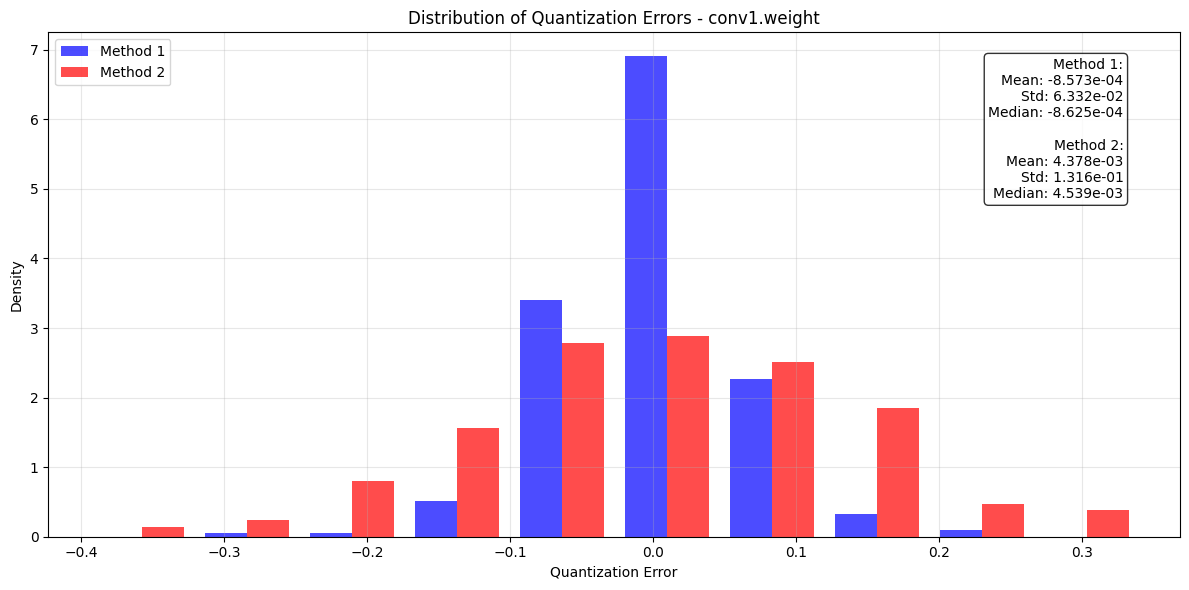

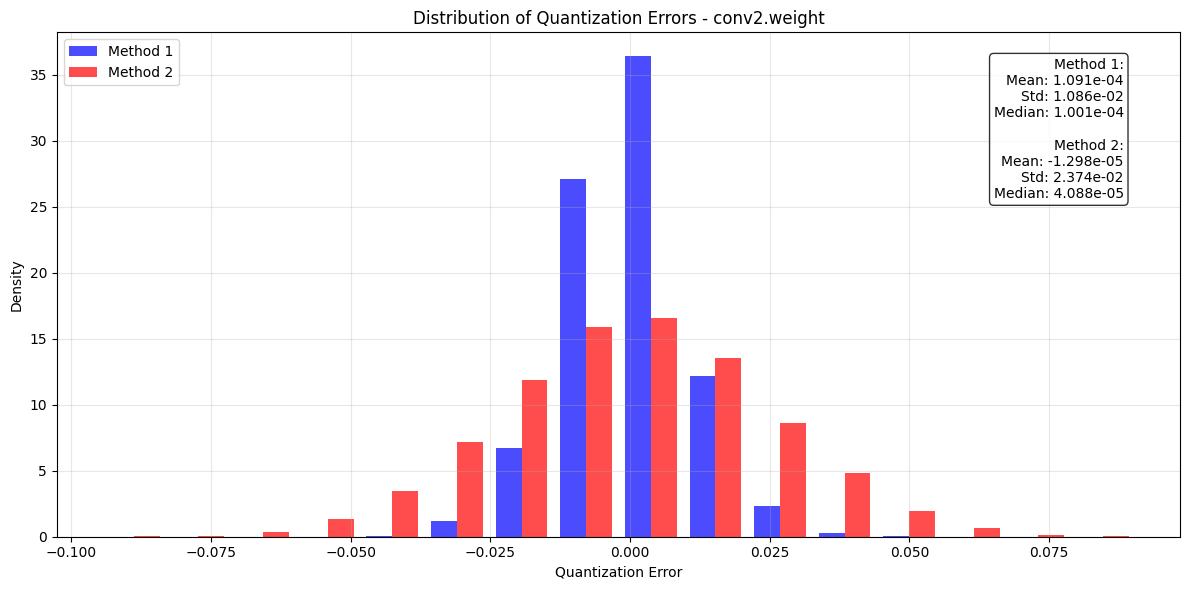

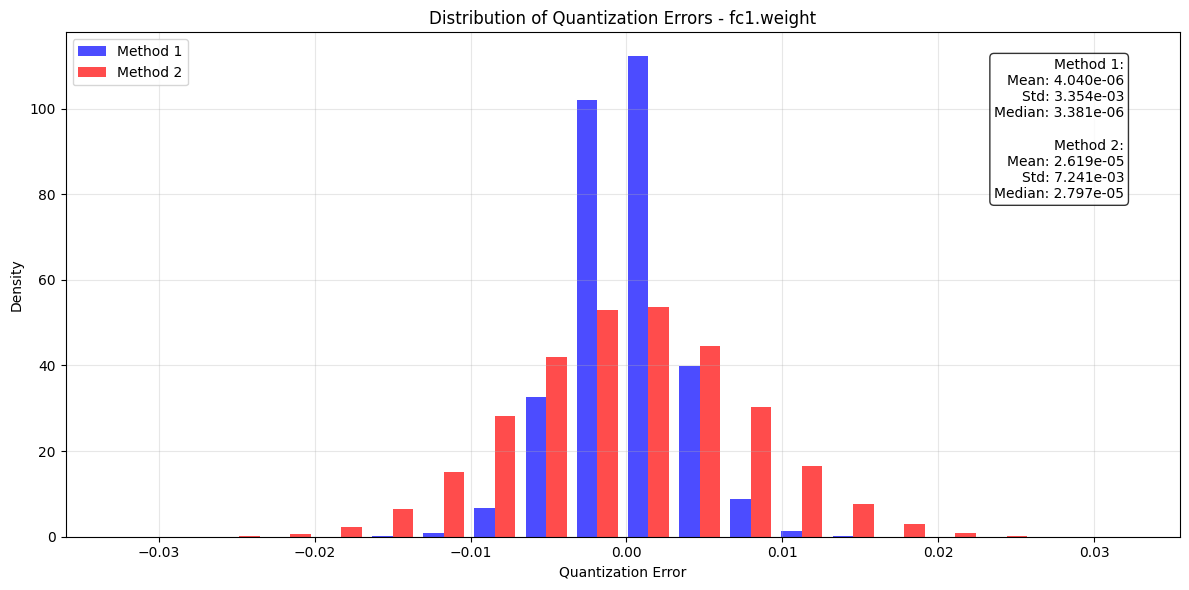

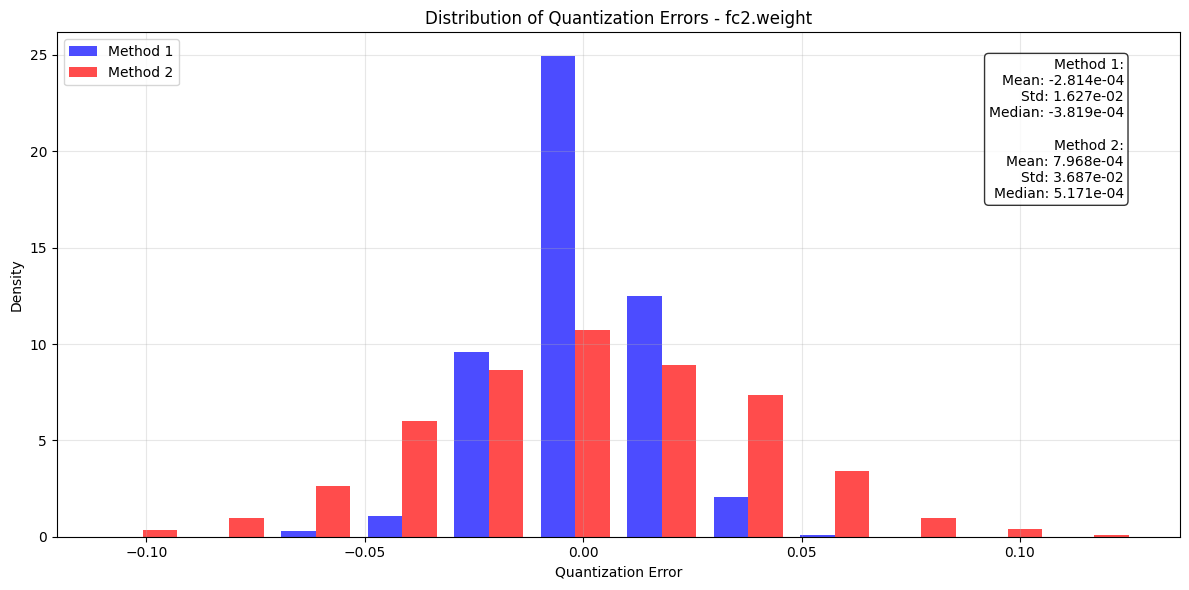

In [ ]:
# Plot histograms for all layers
stats = plot_quantization_errors_histogram(CorbinFL_dir, ldpfl_dir, save_path='layer_histograms.png')

# # Print layer-wise statistics if needed
# for layer_name, layer_stats in stats.items():
#     print(f"\nLayer: {layer_name}")
#     print("Method 1:", layer_stats['method1'])
#     print("Method 2:", layer_stats['method2'])

/tmp/ipykernel_27706/1829329321.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  before_updates = torch.load(f"{checkpoint_dir}/round_0_updates_before.pt")
/tmp/ipykernel

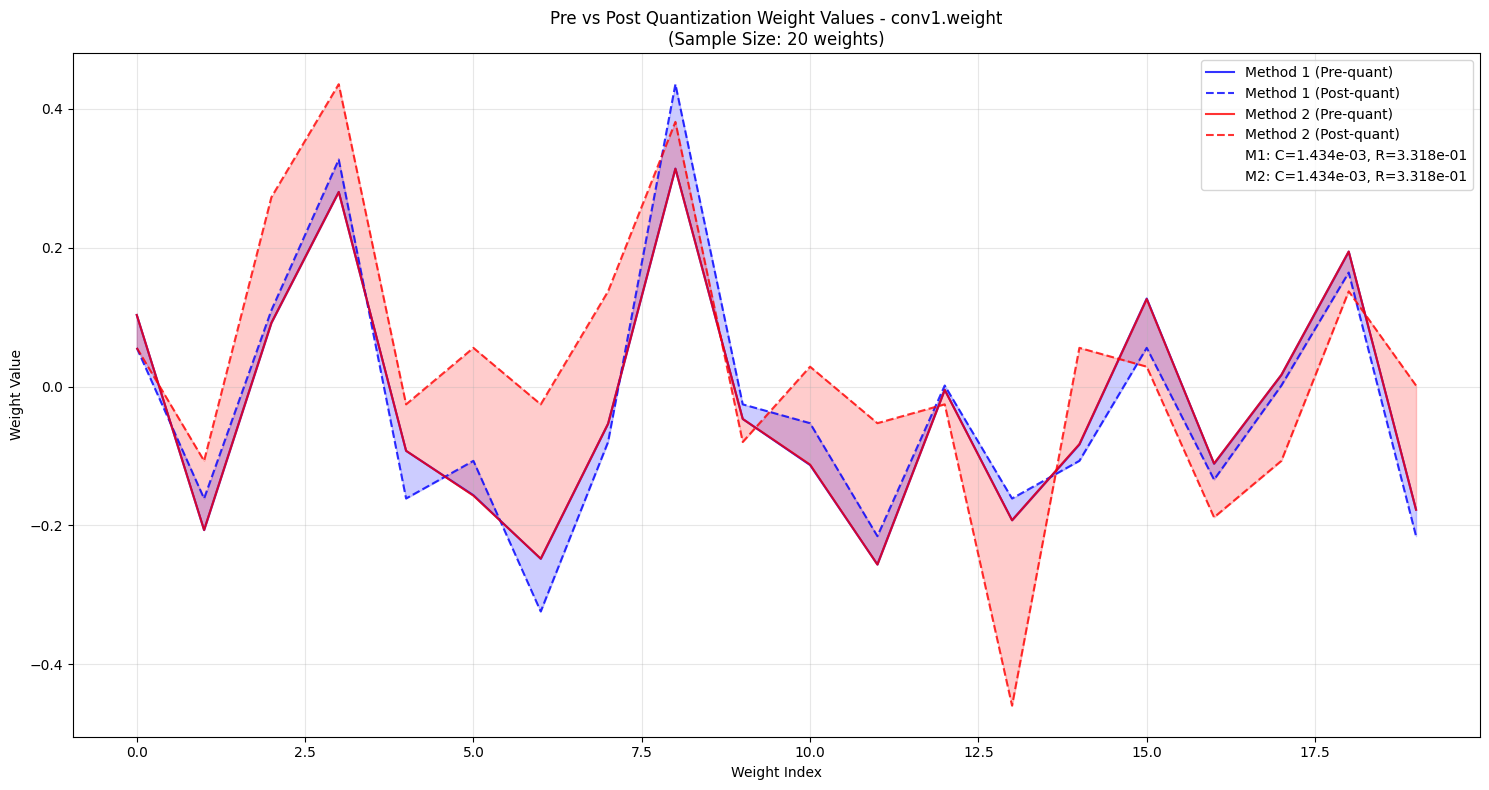

In [ ]:
def plot_layer_quantization(method1_dir, method2_dir, layer_name='conv1.weight', num_samples=100, save_path=None):
    """
    Plot pre and post quantization averages for a single layer.
    
    Args:
        method1_dir: Directory for first method's data
        method2_dir: Directory for second method's data
        layer_name: Name of the layer to visualize (default: 'conv1.weight')
        num_samples: Number of weights to plot (default: 100)
        save_path: Optional path to save the figure
    """
    # Load data for both methods
    method1_data = load_and_process_all_layers(method1_dir)
    method2_data = load_and_process_all_layers(method2_dir)
    
    # Get layer data
    m1_layer = method1_data[layer_name]
    m2_layer = method2_data[layer_name]
    
    # Get total weights in this layer
    total_weights = len(m1_layer['pre_quant_avg'])
    
    # Calculate sampling indices
    if total_weights > num_samples:
        indices = np.linspace(0, total_weights-1, num_samples, dtype=int)
    else:
        indices = np.arange(total_weights)
        num_samples = total_weights
    
    # Sample the data
    pre_quant_m1 = m1_layer['pre_quant_avg'][indices].numpy()
    post_quant_m1 = m1_layer['post_quant_avg'][indices].numpy()
    pre_quant_m2 = m2_layer['pre_quant_avg'][indices].numpy()
    post_quant_m2 = m2_layer['post_quant_avg'][indices].numpy()
    
    # Create x-axis points
    x = np.arange(len(indices))
    
    # Create the plot
    plt.figure(figsize=(15, 8))
    
    # Plot Method 1
    plt.plot(x, pre_quant_m1, color='blue', alpha=0.8, label='Method 1 (Pre-quant)', linewidth=1.5)
    plt.plot(x, post_quant_m1, color='blue', linestyle='--', alpha=0.8, label='Method 1 (Post-quant)', linewidth=1.5)
    plt.fill_between(x, pre_quant_m1, post_quant_m1, color='blue', alpha=0.2)
    
    # Plot Method 2
    plt.plot(x, pre_quant_m2, color='red', alpha=0.8, label='Method 2 (Pre-quant)', linewidth=1.5)
    plt.plot(x, post_quant_m2, color='red', linestyle='--', alpha=0.8, label='Method 2 (Post-quant)', linewidth=1.5)
    plt.fill_between(x, pre_quant_m2, post_quant_m2, color='red', alpha=0.2)
    
    # Add C and R values in the legend
    plt.plot([], [], ' ', label=f'M1: C={m1_layer["C"]:.3e}, R={m1_layer["R"]:.3e}')
    plt.plot([], [], ' ', label=f'M2: C={m2_layer["C"]:.3e}, R={m2_layer["R"]:.3e}')
    
    # Customize the plot
    plt.xlabel('Weight Index')
    plt.ylabel('Weight Value')
    plt.title(f'Pre vs Post Quantization Weight Values - {layer_name}\n(Sample Size: {num_samples} weights)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Adjust layout
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()

plot_layer_quantization(CorbinFL_dir, ldpfl_dir, layer_name='conv1.weight', num_samples=20)
